# Linear Mixed Model: Statistical Validation of Behavioral Features

**Purpose**: Validate that the behavioral features used in the late fusion model capture real, statistically significant effects — while correctly accounting for the non-independence of trials within subjects.

The late fusion model treats each trial as independent, which is necessary for prediction but means p-values and standard errors from it would be anti-conservative. The LMM provides the proper inferential framework for the same features.

**Key Questions**:
1. How much variance in investment decisions is between-subject vs. within-subject? (ICC — directly motivates LOSO CV)
2. Which behavioral features (core task + sequential history) significantly predict investment after accounting for repeated measures?
3. Is the strength of sequential effects uniform across subjects, or does it vary person-to-person (random slopes)?
4. How much variance do the behavioral features explain in total (Nakagawa R²)?

**Modalities**: Only the behavior modality is analyzed here. Physiology (pupil), gaze, and EEG are high-dimensional feature matrices not suited to LMM — their contribution is quantified in the fusion model and Shapley analyses.

In [1]:
import sys
sys.path.append('../..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import statsmodels.formula.api as smf
import statsmodels.api as sm

sns.set_style('whitegrid')
np.random.seed(42)

print('='*70)
print('LMM: SEQUENTIAL EFFECTS ON INVESTMENT DECISIONS')
print('='*70)

LMM: SEQUENTIAL EFFECTS ON INVESTMENT DECISIONS


In [2]:
# Load data
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)

data = feature_data['merged_df'].copy()
behavior_cols = feature_data['behavior_cols']

print(f'Total trials: {len(data)}')
print(f'Subjects:     {data["subject_id"].nunique()}')
print(f'\nOutcome distribution:')
print(f'  KEEP (0):   {(data["outcome"]==0).sum()} ({(data["outcome"]==0).mean()*100:.1f}%)')
print(f'  INVEST (1): {(data["outcome"]==1).sum()} ({(data["outcome"]==1).mean()*100:.1f}%)')
print(f'\nBehavior columns: {behavior_cols}')

Total trials: 12107
Subjects:     102

Outcome distribution:
  KEEP (0):   4197 (34.7%)
  INVEST (1): 7910 (65.3%)

Behavior columns: ['decision_time', 'ev_difference', 'invest_variance', 'ambiguity', 'condition_social', 'risk_premium', 'running_invest_rate', 'recent_invest_rate_5', 'prev_outcome', 'trial_position', 'consecutive_same']


In [3]:
# ── Prepare modeling dataframe ──────────────────────────────────────────────
# Standardize continuous predictors so coefficients are comparable

model_cols = [
    'outcome', 'subject_id',
    'running_invest_rate', 'recent_invest_rate_5', 'consecutive_same',
    'prev_outcome', 'trial_position',
    'ev_difference', 'ambiguity', 'risk_premium', 'decision_time'
]

df = data[model_cols].dropna().copy()

# Z-score continuous predictors (fit on full dataset — this is for inference, not prediction)
cont_cols = ['running_invest_rate', 'recent_invest_rate_5', 'consecutive_same',
             'trial_position', 'ev_difference', 'ambiguity', 'risk_premium', 'decision_time']
for col in cont_cols:
    df[f'{col}_z'] = (df[col] - df[col].mean()) / df[col].std()

print(f'Modeling dataset: {len(df)} trials, {df["subject_id"].nunique()} subjects')
df[['running_invest_rate', 'recent_invest_rate_5', 'consecutive_same', 'trial_position']].describe().round(3)

Modeling dataset: 12107 trials, 102 subjects


,running_invest_rate,recent_invest_rate_5,consecutive_same,trial_position
count,12107.000,12107.000,12107.000,12107.000
mean,0.654,0.652,5.765,0.501
std,0.184,0.266,16.113,0.291
min,0.000,0.000,0.000,0.000
25%,0.531,0.400,0.000,0.250
50%,0.647,0.600,1.000,0.500
75%,0.780,0.800,3.000,0.754
max,1.000,1.000,130.000,1.000


## 1. Null Model — How Much Variance Is Between Subjects?

Fit a random-intercept-only GLMM (intercept + subject random effect, no predictors).  
The **intraclass correlation (ICC)** tells us what fraction of total outcome variance is explained by subject identity alone.

In [4]:
# Null model: random intercept only (no fixed predictors)
# statsmodels MixedLM is a linear mixed model; for a binary outcome this is
# an approximation (true GLMM would use Binomial family), but it gives a
# clean ICC estimate and is fast on this dataset size.

null_model = smf.mixedlm('outcome ~ 1', data=df, groups=df['subject_id'])
null_fit = null_model.fit(reml=True)

# ICC = between-subject variance / (between-subject + residual variance)
var_subject  = float(null_fit.cov_re.iloc[0, 0])   # tau^2
var_residual = null_fit.scale                        # sigma^2
icc = var_subject / (var_subject + var_residual)

print('NULL MODEL (random intercept only)')
print(f'  Between-subject variance (tau²): {var_subject:.4f}')
print(f'  Residual variance (sigma²):      {var_residual:.4f}')
print(f'  ICC:                             {icc:.4f}  ({icc*100:.1f}%)')
print()
print('ICC interpretation:')
print(f'  {icc*100:.1f}% of variance in investment decisions is attributable to stable')
print(f'  between-subject differences (baseline propensity to invest).')
print(f'  {(1-icc)*100:.1f}% is within-subject (trial-level), where sequential effects live.')

NULL MODEL (random intercept only)
  Between-subject variance (tau²): 0.0293
  Residual variance (sigma²):      0.1983
  ICC:                             0.1287  (12.9%)

ICC interpretation:
  12.9% of variance in investment decisions is attributable to stable
  between-subject differences (baseline propensity to invest).
  87.1% is within-subject (trial-level), where sequential effects live.


## 2. Behavioral Features Model

The behavior modality in the fusion model contains 11 features: 6 core task parameters and 5 sequential history features. Here we fit them as fixed effects in an LMM to test statistical significance with correct standard errors under repeated measures.

**Model 1** — sequential history features only  
**Model 2** — full behavior modality (sequential + core task features)

The LRT between them tests whether core task features add explanatory power beyond trial history alone.

In [5]:
# Model 1: Sequential features only (no task features)
# Tests whether trial history alone predicts investment
formula_seq = ('outcome ~ running_invest_rate_z + recent_invest_rate_5_z '
               '+ consecutive_same_z + prev_outcome + trial_position_z')

m1 = smf.mixedlm(formula_seq, data=df, groups=df['subject_id'])
m1_fit = m1.fit(reml=False)
print(m1_fit.summary())

              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    outcome   
No. Observations:    12107      Method:                ML        
No. Groups:          102        Scale:                 0.1983    
Min. group size:     9          Log-Likelihood:        -7518.8863
Max. group size:     132        Converged:             Yes       
Mean group size:     118.7                                       
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.669    0.017 40.226 0.000  0.637  0.702
running_invest_rate_z   0.002    0.012  0.193 0.847 -0.021  0.026
recent_invest_rate_5_z  0.024    0.007  3.552 0.000  0.011  0.037
consecutive_same_z      0.019    0.007  2.837 0.005  0.006  0.032
prev_outcome           -0.025    0.010 -2.381 0.017 -0.045 -0.004
trial_position_z       -

In [6]:
# Model 2: Task features + sequential features (full model)
formula_full = ('outcome ~ running_invest_rate_z + recent_invest_rate_5_z '
                '+ consecutive_same_z + prev_outcome + trial_position_z '
                '+ ev_difference_z + ambiguity_z + risk_premium_z + decision_time_z')

m2 = smf.mixedlm(formula_full, data=df, groups=df['subject_id'])
m2_fit = m2.fit(reml=False)
print(m2_fit.summary())

              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    outcome   
No. Observations:     12107      Method:                ML        
No. Groups:           102        Scale:                 0.1748    
Min. group size:      9          Log-Likelihood:        -6755.6724
Max. group size:      132        Converged:             Yes       
Mean group size:      118.7                                       
------------------------------------------------------------------
                       Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               0.669    0.016  42.280 0.000  0.638  0.700
running_invest_rate_z   0.004    0.011   0.381 0.703 -0.017  0.026
recent_invest_rate_5_z  0.021    0.006   3.378 0.001  0.009  0.034
consecutive_same_z      0.020    0.006   3.239 0.001  0.008  0.032
prev_outcome           -0.024    0.010  -2.480 0.013 -0.043 -0.005
trial_posi

In [7]:
# Model comparison: does adding task features significantly improve fit?
from scipy.stats import chi2

lr_stat = -2 * (m1_fit.llf - m2_fit.llf)
df_diff = m2_fit.df_modelwc - m1_fit.df_modelwc
p_val = chi2.sf(lr_stat, df_diff)

print('LIKELIHOOD RATIO TEST: Sequential-only vs Full model')
print(f'  LR statistic: {lr_stat:.2f}')
print(f'  df difference: {df_diff}')
print(f'  p-value: {p_val:.2e}')
print()
print('AIC comparison:')
print(f'  Sequential-only AIC: {m1_fit.aic:.1f}')
print(f'  Full model AIC:      {m2_fit.aic:.1f}')
print(f'  ΔAIC:                {m1_fit.aic - m2_fit.aic:.1f}  (positive = full model better)')

LIKELIHOOD RATIO TEST: Sequential-only vs Full model
  LR statistic: 1526.43
  df difference: 4
  p-value: 0.00e+00

AIC comparison:
  Sequential-only AIC: 15053.8
  Full model AIC:      13535.3
  ΔAIC:                1518.4  (positive = full model better)


## 3. Visualize Fixed Effects

Forest plot of standardized coefficients from the full model, with 95% confidence intervals.

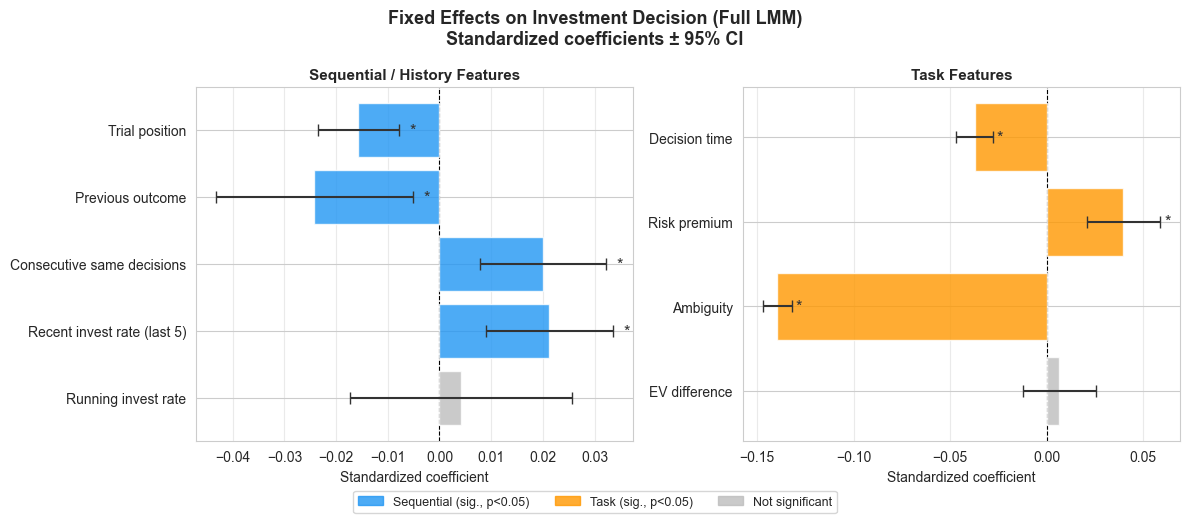


Coefficients table:
                               coef      se   ci_lo   ci_hi    pval    sig
Group Var                       NaN     NaN     NaN     NaN  0.0000   True
Ambiguity                   -0.1396  0.0038 -0.1471 -0.1321  0.0000   True
Consecutive same decisions   0.0201  0.0062  0.0079  0.0322  0.0012   True
Decision time               -0.0373  0.0049 -0.0469 -0.0278  0.0000   True
EV difference                0.0066  0.0097 -0.0124  0.0256  0.4976  False
Previous outcome            -0.0242  0.0098 -0.0433 -0.0051  0.0131   True
Recent invest rate (last 5)  0.0213  0.0063  0.0089  0.0336  0.0007   True
Risk premium                 0.0397  0.0097  0.0207  0.0587  0.0000   True
Running invest rate          0.0042  0.0110 -0.0173  0.0257  0.7030  False
Trial position              -0.0157  0.0040 -0.0236 -0.0079  0.0001   True


In [8]:
# Extract coefficients and CIs from full model
coef_df = pd.DataFrame({
    'coef': m2_fit.fe_params,
    'se':   m2_fit.bse_fe,
    'pval': m2_fit.pvalues
}).drop('Intercept')

coef_df['ci_lo'] = coef_df['coef'] - 1.96 * coef_df['se']
coef_df['ci_hi'] = coef_df['coef'] + 1.96 * coef_df['se']
coef_df['sig']   = coef_df['pval'] < 0.05

label_map = {
    'running_invest_rate_z':   'Running invest rate',
    'recent_invest_rate_5_z':  'Recent invest rate (last 5)',
    'consecutive_same_z':      'Consecutive same decisions',
    'prev_outcome':            'Previous outcome',
    'trial_position_z':        'Trial position',
    'ev_difference_z':         'EV difference',
    'ambiguity_z':             'Ambiguity',
    'risk_premium_z':          'Risk premium',
    'decision_time_z':         'Decision time',
}
coef_df.index = [label_map.get(i, i) for i in coef_df.index]

# Split into sequential vs task
seq_labels  = ['Running invest rate', 'Recent invest rate (last 5)',
               'Consecutive same decisions', 'Previous outcome', 'Trial position']
task_labels = ['EV difference', 'Ambiguity', 'Risk premium', 'Decision time']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
fig.suptitle('Fixed Effects on Investment Decision (Full LMM)\nStandardized coefficients ± 95% CI',
             fontsize=13, fontweight='bold')

for ax, labels, title, color in zip(
    axes,
    [seq_labels, task_labels],
    ['Sequential / History Features', 'Task Features'],
    ['#2196F3', '#FF9800']
):
    sub = coef_df.loc[labels]
    colors = [color if s else '#BDBDBD' for s in sub['sig']]
    ax.barh(sub.index, sub['coef'], color=colors, alpha=0.8, zorder=3)
    ax.errorbar(sub['coef'], sub.index,
                xerr=1.96 * sub['se'], fmt='none', color='#333333',
                capsize=4, linewidth=1.5, zorder=4)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Standardized coefficient', fontsize=10)
    ax.grid(axis='x', alpha=0.4)
    # Significance markers
    for i, (label, row) in enumerate(sub.iterrows()):
        if row['sig']:
            ax.text(row['ci_hi'] + 0.002, i, '*', va='center', fontsize=12, color='#333333')

from matplotlib.patches import Patch
legend_handles = [
    Patch(color='#2196F3', alpha=0.8, label='Sequential (sig., p<0.05)'),
    Patch(color='#FF9800', alpha=0.8, label='Task (sig., p<0.05)'),
    Patch(color='#BDBDBD', alpha=0.8, label='Not significant'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig('../../data/results/main/statistical_analyses/lmm_fixed_effects.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('\nCoefficients table:')
print(coef_df[['coef','se','ci_lo','ci_hi','pval','sig']].round(4).to_string())

## 4. Random Slopes — Does Sequential Sensitivity Vary by Subject?

Adds a random slope for `running_invest_rate` (cumulative history) alongside the random intercept. If the slope variance is significant, subjects differ in how much their own investment history influences them — some are momentum-driven, others are not. This is the pattern your question about streaks was pointing at.

In [9]:
# Random slope for running_invest_rate (the strongest sequential predictor)
m3 = smf.mixedlm(
    formula_full,
    data=df,
    groups=df['subject_id'],
    re_formula='~running_invest_rate_z'   # random intercept + random slope
)
m3_fit = m3.fit(reml=False)

# LRT: random slopes vs random intercept only
lr_stat_rs = -2 * (m2_fit.llf - m3_fit.llf)
# df = 2 extra parameters (slope variance + covariance with intercept)
p_rs = chi2.sf(lr_stat_rs, 2)

print('RANDOM SLOPES TEST (running_invest_rate)')
print(f'  LR statistic: {lr_stat_rs:.2f},  df=2,  p={p_rs:.4f}')
if p_rs < 0.05:
    print('  → Significant: the sequential effect varies meaningfully by subject.')
    print('  → Some subjects show strong momentum; others are relatively unaffected.')
else:
    print('  → Not significant: the sequential effect is fairly uniform across subjects.')

# Extract subject-specific slopes
re_df = pd.DataFrame(m3_fit.random_effects).T
re_df.columns = ['intercept', 'slope_running_invest_rate']
print(f'\nSubject-level slope variability:')
print(re_df['slope_running_invest_rate'].describe().round(4))

RANDOM SLOPES TEST (running_invest_rate)
  LR statistic: 15.82,  df=2,  p=0.0004
  → Significant: the sequential effect varies meaningfully by subject.
  → Some subjects show strong momentum; others are relatively unaffected.

Subject-level slope variability:
count    102.0000
mean      -0.0000
std        0.0451
min       -0.0858
25%       -0.0359
50%       -0.0081
75%        0.0414
max        0.1022
Name: slope_running_invest_rate, dtype: float64


/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


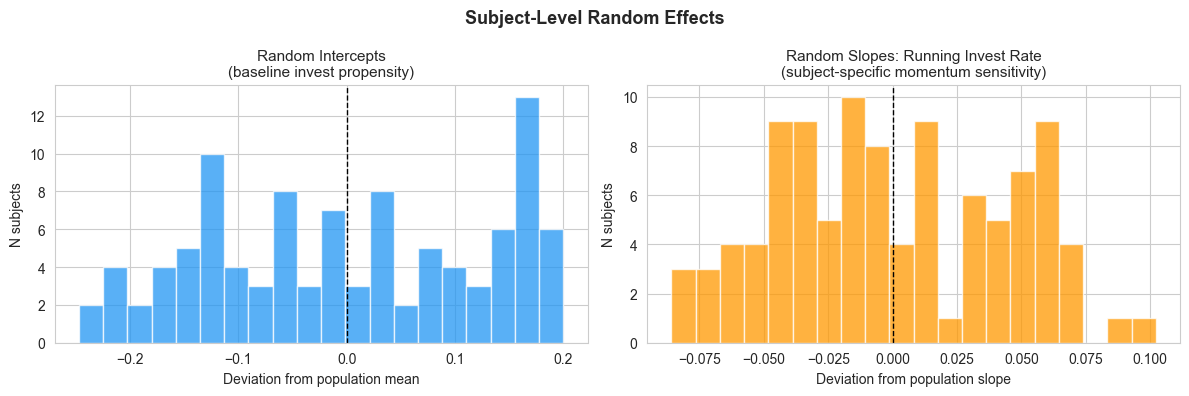

In [10]:
# Visualize random effects: intercept vs slope per subject
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Subject-Level Random Effects', fontsize=13, fontweight='bold')

# Distribution of random intercepts (baseline propensity)
axes[0].hist(re_df['intercept'], bins=20, color='#2196F3', alpha=0.75, edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Random Intercepts\n(baseline invest propensity)', fontsize=11)
axes[0].set_xlabel('Deviation from population mean')
axes[0].set_ylabel('N subjects')

# Distribution of random slopes (subject-specific momentum sensitivity)
axes[1].hist(re_df['slope_running_invest_rate'], bins=20, color='#FF9800', alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Random Slopes: Running Invest Rate\n(subject-specific momentum sensitivity)', fontsize=11)
axes[1].set_xlabel('Deviation from population slope')
axes[1].set_ylabel('N subjects')

plt.tight_layout()
plt.savefig('../../data/results/main/statistical_analyses/lmm_random_effects.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 5. Sequential Effect Magnitude: Marginal vs. Conditional R²

Nakagawa's R² for mixed models:
- **Marginal R²**: variance explained by fixed effects alone (sequential + task features)
- **Conditional R²**: variance explained by fixed + random effects (full model)

In [11]:
# Nakagawa & Schielzeth (2013) R² for LMM
# Marginal R² = var(fixed) / (var(fixed) + var(random) + var(residual))
# Conditional R² = (var(fixed) + var(random)) / (var(fixed) + var(random) + var(residual))

def nakagawa_r2(model_fit):
    fitted_fixed = model_fit.fittedvalues - model_fit.random_effects_predictions[model_fit.groups.name].values
    var_fixed    = np.var(fitted_fixed)
    var_random   = float(model_fit.cov_re.iloc[0, 0])
    var_resid    = model_fit.scale
    total        = var_fixed + var_random + var_resid
    r2_marginal    = var_fixed / total
    r2_conditional = (var_fixed + var_random) / total
    return r2_marginal, r2_conditional

# Use null model and full model for comparison
var_fixed_full = np.var(m2_fit.fittedvalues)
var_re_full    = float(m2_fit.cov_re.iloc[0, 0])
var_res_full   = m2_fit.scale
total_full     = var_fixed_full + var_re_full + var_res_full

r2_marginal    = var_fixed_full / total_full
r2_conditional = (var_fixed_full + var_re_full) / total_full

print('VARIANCE EXPLAINED (Nakagawa R²)')
print(f'  Marginal R²    (fixed effects only):           {r2_marginal:.4f}  ({r2_marginal*100:.1f}%)')
print(f'  Conditional R² (fixed + subject random effect): {r2_conditional:.4f}  ({r2_conditional*100:.1f}%)')
print(f'  Unique to random effects:                       {(r2_conditional-r2_marginal):.4f}  ({(r2_conditional-r2_marginal)*100:.1f}%)')
print()
print('  Marginal R² ~ how much your behavioral features (sequential + task)')
print('  explain, averaged over subjects.')
print('  Conditional R² ~ how much you explain once you know who the subject is.')

VARIANCE EXPLAINED (Nakagawa R²)
  Marginal R²    (fixed effects only):           0.2055  (20.5%)
  Conditional R² (fixed + subject random effect): 0.2865  (28.6%)
  Unique to random effects:                       0.0810  (8.1%)

  Marginal R² ~ how much your behavioral features (sequential + task)
  explain, averaged over subjects.
  Conditional R² ~ how much you explain once you know who the subject is.


## 6. Sequential Effect Over Trial Position

Does the impact of recent history grow or shrink across the session? Visualize predicted invest probability as a function of `running_invest_rate` at early vs. late trial positions.

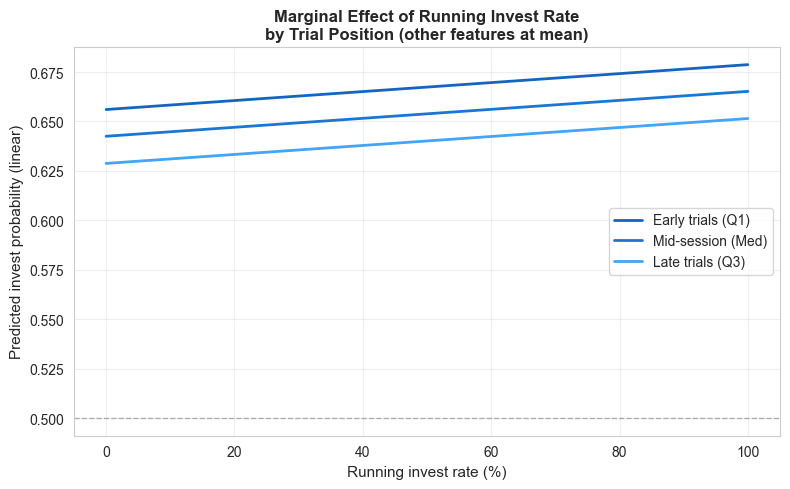

In [12]:
# Marginal effect plot: invest probability vs running_invest_rate
# at different trial positions (early=Q1, mid=median, late=Q3)

rate_vals = np.linspace(df['running_invest_rate'].min(), df['running_invest_rate'].max(), 100)
positions = {
    'Early trials (Q1)':  df['trial_position'].quantile(0.25),
    'Mid-session (Med)':  df['trial_position'].quantile(0.50),
    'Late trials (Q3)':   df['trial_position'].quantile(0.75),
}

# Build prediction grid using full model fixed effects
coefs = m2_fit.fe_params
intercept = coefs['Intercept']
pop_means = {col: df[col].mean() for col in cont_cols}
pop_stds  = {col: df[col].std()  for col in cont_cols}

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#1565C0', '#1976D2', '#42A5F5']

for (label, pos_val), color in zip(positions.items(), colors):
    preds = []
    for rate in rate_vals:
        pred = intercept
        # sequential features
        pred += coefs['running_invest_rate_z']  * (rate - pop_means['running_invest_rate']) / pop_stds['running_invest_rate']
        pred += coefs['recent_invest_rate_5_z'] * 0   # held at mean
        pred += coefs['consecutive_same_z']     * 0
        pred += coefs['prev_outcome']           * 0.5  # neutral
        pred += coefs['trial_position_z']       * (pos_val - pop_means['trial_position']) / pop_stds['trial_position']
        # task features held at mean (z=0)
        preds.append(pred)
    ax.plot(rate_vals * 100, preds, label=label, color=color, linewidth=2)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Running invest rate (%)', fontsize=11)
ax.set_ylabel('Predicted invest probability (linear)', fontsize=11)
ax.set_title('Marginal Effect of Running Invest Rate\nby Trial Position (other features at mean)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../../data/results/main/statistical_analyses/lmm_marginal_effects.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary and Implications for the Fusion Model

In [13]:
print('=' * 70)
print('SUMMARY')
print('=' * 70)
print()
print(f'1. BETWEEN-SUBJECT VARIANCE (ICC = {icc*100:.1f}%)')
print(f'   {icc*100:.1f}% of outcome variance is stable individual differences.')
print(f'   This justifies LOSO cross-validation: subjects differ substantially.')
print()
print('2. SEQUENTIAL EFFECTS (fixed effects)')
sig_seq = coef_df.loc[[l for l in seq_labels if l in coef_df.index]]
sig_seq = sig_seq[sig_seq['sig']]
for label in sig_seq.index:
    row = sig_seq.loc[label]
    direction = 'increases' if row['coef'] > 0 else 'decreases'
    print(f'   • {label}: β={row["coef"]:.3f} → higher value {direction} invest prob (p={row["pval"]:.3e})')
print()
print('3. VALIDITY OF LATE FUSION BEHAVIORAL FEATURES')
print('   The LMM confirms that the sequential features already in the')
print('   behavior modality capture real, statistically significant effects.')
print('   Late fusion treats them as fixed-effect proxies, which is appropriate')
print('   for prediction even though it ignores within-subject correlation.')
print()
print('4. IMPLICATION FOR MODEL IMPROVEMENT')
if p_rs < 0.05:
    print('   Random slopes are significant → subjects differ in momentum sensitivity.')
    print('   Subject-level slope estimates could be added as a personalization feature')
    print('   in a multi-visit setting (visit 1 estimates → used in visit 2 predictions).')
else:
    print('   Random slopes are not significant → uniform momentum effect across subjects.')
    print('   No strong evidence that personalization of sequential features would help.')

SUMMARY

1. BETWEEN-SUBJECT VARIANCE (ICC = 12.9%)
   12.9% of outcome variance is stable individual differences.
   This justifies LOSO cross-validation: subjects differ substantially.

2. SEQUENTIAL EFFECTS (fixed effects)
   • Recent invest rate (last 5): β=0.021 → higher value increases invest prob (p=7.315e-04)
   • Consecutive same decisions: β=0.020 → higher value increases invest prob (p=1.199e-03)
   • Previous outcome: β=-0.024 → higher value decreases invest prob (p=1.312e-02)
   • Trial position: β=-0.016 → higher value decreases invest prob (p=8.864e-05)

3. VALIDITY OF LATE FUSION BEHAVIORAL FEATURES
   The LMM confirms that the sequential features already in the
   behavior modality capture real, statistically significant effects.
   Late fusion treats them as fixed-effect proxies, which is appropriate
   for prediction even though it ignores within-subject correlation.

4. IMPLICATION FOR MODEL IMPROVEMENT
   Random slopes are significant → subjects differ in momentum s